# Entity Resolution Analysis Dashboard

This notebook provides an interactive analysis of the Entity Resolution results, focusing on:

- Match Score Distribution
- Geographical Match Analysis
- Matching Pattern Analysis
- Acceptance Rate Analysis
- Interactive Visualizations

The visualizations are designed to help analysts understand the matching patterns, identify potential areas for improvement, and validate the quality of matches.

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import matplotlib.pyplot as plt
import os

# Set style for static plots
plt.style.use('default')
sns.set_theme(style="whitegrid")

# Project and data
PROJECT_ROOT = Path('..').resolve()
er_results = pd.read_csv(PROJECT_ROOT / 'data/processed/entity_resolution.csv')

# === Dashboard parameters (tweak these) ===
# Batch/window defaults
BATCH_SIZE = 100                  # number of rows per batch when using row_index batching
ROLLING_WINDOW_BATCHES = 5       # rolling window (in batches) for batch-based trends
ROLLING_WINDOW_DAYS = 7          # rolling window (in days) when using a date axis

# Export and theming
EXPORT_HTML = True
EXPORT_PATH = PROJECT_ROOT / 'outputs' / 'html' / 'er_dashboard.html'
COLORBLIND_PALETTE = ['#0072B2', '#D55E00', '#009E73']  # blue, orange, green

# Ensure export directory exists
if EXPORT_HTML:
    os.makedirs(EXPORT_PATH.parent, exist_ok=True)

print(f"Loaded {len(er_results):,} records")
er_results.head()

Loaded 2,951 records


,row_index,status,score,best_cand_index,best_cand_name,best_cand_country,best_cand_id
0,0,accept,0.7167,1,New Millennium Network Private Limited | MNET ...,Pakistan,26e22210-93e5-11eb-b997-8dd98d09cf25
1,1,maybe,0.5591,2,Private Helipad Ali Villa,Pakistan,01004641-1dd8-11ef-9268-316fc8e174dd
2,2,maybe,0.5926,2,24seven Research Network,India,8266efc1-13e7-11ec-aa14-7bf90e1e10f1
3,3,maybe,0.5700,2,Emeriosoft | EMERIOSOFT Private L.T.D.,Pakistan,0183f0b2-93e5-11eb-be5a-4f810ab55f2e
4,4,accept,0.7167,1,Asiatic Public Relations Network Private Limited,Pakistan,87bb7cde-93e4-11eb-8474-3bbe2d07207d


## 1. Match Score Distribution Analysis

The following visualizations show the distribution of match scores across different categories, helping us understand the confidence levels of our matches.

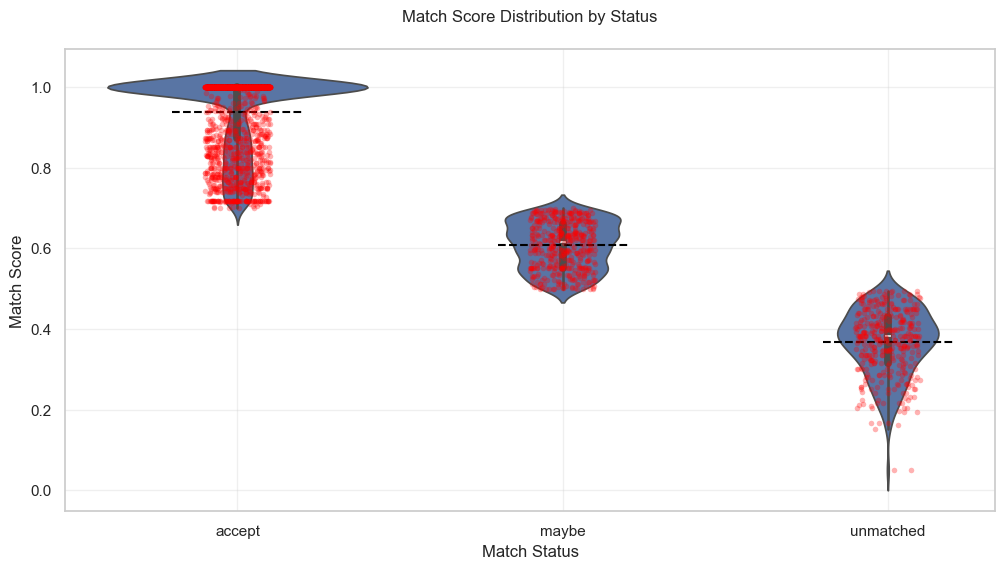


Score Statistics by Status:
--------------------------------------------------
            count      mean       std   min       25%      50%      75%  \
status                                                                    
accept     2124.0  0.938876  0.095724  0.70  0.873500  1.00000  1.00000   
maybe       460.0  0.607142  0.058316  0.50  0.550525  0.61475  0.65975   
unmatched   367.0  0.367184  0.081421  0.05  0.316700  0.38330  0.42860   

              max  
status             
accept     1.0000  
maybe      0.6986  
unmatched  0.4944  


In [25]:
# Create a violin plot with individual points
plt.figure(figsize=(12, 6))
sns.violinplot(data=er_results, x='status', y='score', inner='box')
sns.stripplot(data=er_results, x='status', y='score', color='red', alpha=0.3, size=4)

plt.title('Match Score Distribution by Status', pad=20)
plt.xlabel('Match Status')
plt.ylabel('Match Score')

# Add mean score lines
for status in er_results['status'].unique():
    mean_score = er_results[er_results['status'] == status]['score'].mean()
    plt.hlines(mean_score, 
              xmin=list(er_results['status'].unique()).index(status) - 0.2,
              xmax=list(er_results['status'].unique()).index(status) + 0.2,
              colors='black', linestyles='dashed', label=f'Mean ({status})')

plt.grid(True, alpha=0.3)
plt.show()

# Print summary statistics
print("\nScore Statistics by Status:")
print("-" * 50)
print(er_results.groupby('status')['score'].describe())

## 2. Geographical Match Analysis

Let's analyze how the matching performance varies across different countries and regions.

In [26]:
# Calculate country-level statistics
country_stats = er_results.groupby('best_cand_country').agg({
    'status': ['count', lambda x: (x == 'accept').mean()],
    'score': 'mean'
}).round(3)

country_stats.columns = ['total_matches', 'acceptance_rate', 'avg_score']
country_stats = country_stats.sort_values('total_matches', ascending=False)

# Create an interactive choropleth map
fig = px.choropleth(
    country_stats.reset_index(),
    locations='best_cand_country',
    locationmode='country names',
    color='acceptance_rate',
    hover_data=['total_matches', 'avg_score'],
    color_continuous_scale='RdYlGn',
    title='Match Acceptance Rate by Country'
)

fig.update_layout(
    title_x=0.5,
    geo=dict(showframe=False),
    width=1000,
    height=600
)
fig.show()

# Show top 10 countries by volume
print("\nTop 10 Countries by Match Volume:")
print("-" * 50)
print(country_stats.head(10))

C:\Users\vladp\AppData\Local\Temp\ipykernel_12600\2906077511.py:11: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.




Top 10 Countries by Match Volume:
--------------------------------------------------
                   total_matches  acceptance_rate  avg_score
best_cand_country                                           
Denmark                      578            0.585      0.725
Norway                       321            0.620      0.757
United States                244            0.857      0.911
Malaysia                     169            0.781      0.838
Sweden                       162            0.753      0.832
Singapore                    152            0.711      0.795
United Kingdom               128            0.648      0.785
Pakistan                     113            0.611      0.760
Thailand                      95            0.737      0.821
China                         81            0.840      0.882


## 3. Score Distribution Patterns

Let's analyze the patterns in match scores using density plots and interactive visualizations.

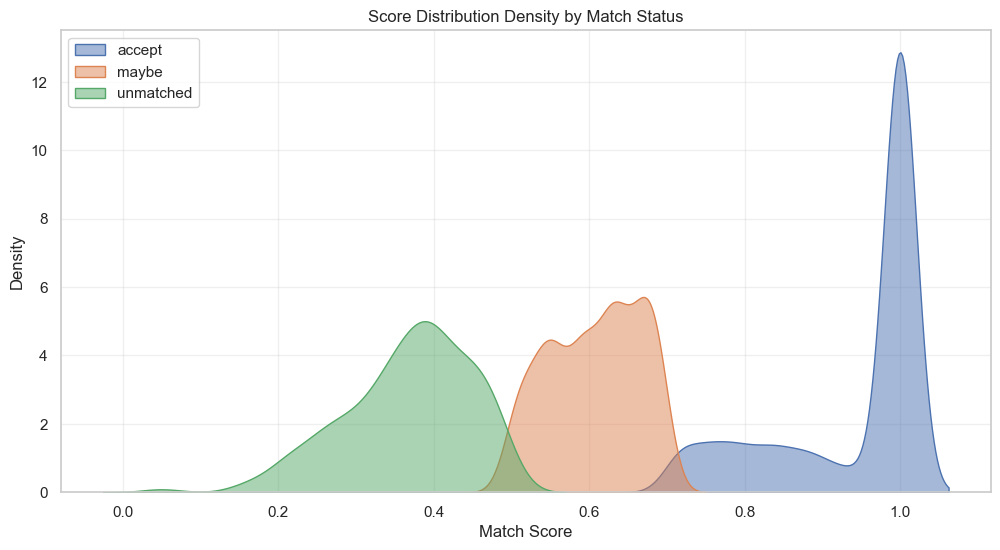

In [27]:
# Create KDE plot for score distribution
plt.figure(figsize=(12, 6))

for status in er_results['status'].unique():
    sns.kdeplot(
        data=er_results[er_results['status'] == status],
        x='score',
        fill=True,
        alpha=0.5,
        label=status
    )

plt.title('Score Distribution Density by Match Status')
plt.xlabel('Match Score')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Create an interactive histogram
fig = px.histogram(
    er_results,
    x='score',
    color='status',
    marginal='box',
    nbins=50,
    title='Interactive Score Distribution'
)

fig.update_layout(
    barmode='overlay',
    width=1000,
    height=600
)
fig.show()

## 4. Interactive Match Quality Dashboard

The following dashboard combines multiple visualizations to provide a comprehensive view of match quality metrics.

In [37]:
# Create a more complex dashboard using subplot layout
from plotly.subplots import make_subplots

# Map statuses to colors using the colorblind palette
status_order = ['accept', 'maybe', 'unmatched']
status_colors = {
    'accept': COLORBLIND_PALETTE[2],   # green
    'maybe': COLORBLIND_PALETTE[1],    # orange
    'unmatched': COLORBLIND_PALETTE[0] # blue-ish for contrast
}

# Initialize figure with subplots
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Match Status Distribution', 'Score Distribution by Status', 'Match Trends'),
    specs=[[{'type': 'pie'}, {'type': 'box'}],
           [{'type': 'scatter', 'colspan': 2}, None]]
)

# Add pie chart
status_counts = er_results['status'].value_counts()
fig.add_trace(
    go.Pie(labels=status_counts.index, values=status_counts.values, marker={'colors':[status_colors.get(s, None) for s in status_counts.index]}),
    row=1, col=1
)

# Add box plot per status (one trace each) so we can control colors
for s in status_order:
    if s in er_results['status'].unique():
        fig.add_trace(
            go.Box(
                y=er_results.loc[er_results['status'] == s, 'score'],
                name=s,
                marker_color=status_colors.get(s),
                boxmean=True
            ),
            row=1, col=2
        )

# --- Match Trends: prefer a date axis if available ---
date_col = None
# heuristic: look for datetime-like columns
for c in er_results.columns:
    if er_results[c].dtype.kind == 'M':
        date_col = c
        break
# try parsing string columns if no datetime dtype found
if date_col is None:
    for c in er_results.select_dtypes(include='object').columns:
        sample = er_results[c].dropna().head(50).astype(str)
        if sample.empty:
            continue
        parsed = pd.to_datetime(sample, errors='coerce')
        if parsed.notna().sum() / len(sample) > 0.8:
            date_col = c
            break

# Build rolling-series DataFrame
rolling = None
x_axis_title = 'Index'

if date_col is not None:
    try:
        df_time = er_results.copy()
        df_time[date_col] = pd.to_datetime(df_time[date_col], errors='coerce')
        df_time = df_time.dropna(subset=[date_col])
        if not df_time.empty:
            df_time['date_day'] = df_time[date_col].dt.floor('D')
            pivot = df_time.pivot_table(index='date_day', columns='status', values='score', aggfunc='mean')
            rolling = pivot.rolling(window=ROLLING_WINDOW_DAYS, min_periods=1).mean()
            x_axis_title = 'Date'
    except Exception:
        rolling = None

# fallback: use batching by row_index
if rolling is None or rolling.dropna(how='all').empty:
    if 'row_index' in er_results.columns:
        df_batch = er_results.sort_values('row_index').copy()
        df_batch['batch'] = (df_batch['row_index'] // BATCH_SIZE).astype(int)
        pivot = df_batch.pivot_table(index='batch', columns='status', values='score', aggfunc='mean')
        if not pivot.empty:
            rolling = pivot.rolling(window=ROLLING_WINDOW_BATCHES, min_periods=1).mean()
            x_axis_title = f'Batch (size={BATCH_SIZE})'

# If still empty, put an annotation; otherwise draw the series
if rolling is None or rolling.dropna(how='all').empty:
    fig.add_annotation(text='No usable time-series data for Match Trends', xref='paper', yref='paper', x=0.5, y=0.35, showarrow=False, row=2, col=1)
else:
    # Plot each status with styling
    for col in rolling.columns:
        if col not in rolling:
            continue
        fig.add_trace(
            go.Scatter(
                x=rolling.index,
                y=rolling[col],
                name=f'{col} (rolling mean)',
                mode='lines+markers',
                line=dict(color=status_colors.get(col, None), width=2),
                marker=dict(size=4),
                hovertemplate=f'%{{x}}<br>{col}: %{{y:.3f}}<extra>{col}</extra>'
            ),
            row=2, col=1
        )

    # set y-axis limits to sensible range
    fig.update_yaxes(range=[0, 1], row=2, col=1)

# Final layout tweaks for legibility and presentation
fig.update_layout(
    title=dict(text='Entity Resolution Quality Dashboard', x=0.5, xanchor='center'),
    showlegend=True,
    height=840,
    width=1250,
    template='plotly_white',
    legend=dict(title='Status', orientation='v', x=1.02, y=0.95)
)
# Improve fonts and title sizes
fig.update_layout(font=dict(size=12), title_font=dict(size=18))

fig.update_xaxes(title_text=x_axis_title)

# keep a reference to the figure so we can export it later
dashboard_fig = fig

fig.show()

# Print summary metrics
print("\nMatch Quality Metrics:")
print("-" * 50)
print(f"Total Records: {len(er_results):,}")
print(f"Average Match Score: {er_results['score'].mean():.3f}")
print("\nStatus Distribution:")
for status, count in status_counts.items():
    print(f"{status}: {count:,} ({count/len(er_results)*100:.1f}%)")

C:\Users\vladp\AppData\Local\Temp\ipykernel_12600\1174684786.py:53: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

C:\Users\vladp\AppData\Local\Temp\ipykernel_12600\1174684786.py:53: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

C:\Users\vladp\AppData\Local\Temp\ipykernel_12600\1174684786.py:53: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

C:\Users\vladp\AppData\Local\Temp\ipykernel_12600\1174684786.py:53: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please spe


Match Quality Metrics:
--------------------------------------------------
Total Records: 2,951
Average Match Score: 0.816

Status Distribution:
accept: 2,124 (72.0%)
maybe: 460 (15.6%)
unmatched: 367 (12.4%)


## 5) QC Insights (Duplicates & Missingness)
This section uses the pipeline outputs (`data/processed/duplicates.csv` and `data/processed/missingness.csv`) to highlight clusters that need remediation and columns with high missingness.

In [39]:
# QC dashboards based on pipeline outputs
from IPython.display import display

duplicates_path = PROJECT_ROOT / 'data/processed/duplicates.csv'
missing_path = PROJECT_ROOT / 'data/processed/missingness.csv'

duplicates = pd.read_csv(duplicates_path) if duplicates_path.exists() else pd.DataFrame()
missingness = pd.read_csv(missing_path) if missing_path.exists() else pd.DataFrame()

if not duplicates.empty:
    dup_summary = (
        duplicates[['key', 'count']]
        .sort_values('count', ascending=False)
        .head(15)
    )
    fig = px.bar(
        dup_summary,
        x='key',
        y='count',
        title='Top Duplicate Clusters (Top 15)',
        text='count'
    )
    fig.update_layout(xaxis_title='Normalized key', yaxis_title='Cluster size', height=500)
    fig.show()
    display(duplicates.head())
else:
    print('duplicates.csv not found or empty (run pipeline with --qc).')

# Missingness: only plot columns with non-zero missing percent
if not missingness.empty:
    # ensure numeric
    missingness = missingness.copy()
    if 'missing_pct' in missingness.columns:
        missingness['missing_pct'] = pd.to_numeric(missingness['missing_pct'], errors='coerce')
    else:
        # try to compute missing_pct if raw counts available
        if {'missing', 'count'}.issubset(missingness.columns):
            missingness['missing_pct'] = (missingness['missing'] / missingness['count']) * 100
        else:
            missingness['missing_pct'] = 0

    miss_sorted = missingness.sort_values('missing_pct', ascending=False)
    miss_nonzero = miss_sorted[miss_sorted['missing_pct'] > 0]
    if miss_nonzero.empty:
        print('No columns with missing values detected (all missing_pct == 0).')
        display(miss_sorted.head())
    else:
        fig = px.bar(
            miss_nonzero,
            x='column',
            y='missing_pct',
            text='missing_pct',
            title='Percent missing by column'
        )
        fig.update_layout(xaxis_title='Column', yaxis_title='% missing', height=500)
        fig.show()
        display(miss_nonzero.head())
else:
    print('missingness.csv not found or empty (run pipeline with --qc).')

,key,row_indices,count
0,apple distribution international|ireland,"[1886, 1887, 1888, 1889, 1890, 1941, 1942, 194...",10
1,digi telecommunications sdn bhd|malaysia,"[235, 236, 237, 238, 239, 240, 241, 242, 243, ...",10
2,eci media management|sweden,"[315, 316, 317, 318, 319, 320, 321, 322, 323, ...",10
3,tata communications international pte|singapore,"[2191, 2192, 2193, 2194, 2195, 2196, 2197, 219...",10
4,24 seven media network private|pakistan,"[0, 1, 2, 3, 4]",5


No columns with missing values detected (all missing_pct == 0).


,column,missing,missing_pct
0,input_company_name,0,0.0
1,input_main_country,0,0.0


## 6) Feature-Driven Insights (Segments / ESG / Website)
These analyses appear only when the optional hooks are enabled in `config/config.yaml`.

In [20]:
# Optional feature outputs: segments, ESG hints, enrichment
has_segment = 'segment' in er_results.columns
has_esg = {'esg_hint', 'esg_match_terms'}.issubset(er_results.columns)
has_domain = 'has_website' in er_results.columns

if has_segment:
    seg_status = (
        er_results
        .groupby(['segment', 'status'])
        .size()
        .reset_index(name='count')
    )
    fig = px.bar(
        seg_status,
        x='segment',
        y='count',
        color='status',
        title='Status distribution by procurement segment',
        barmode='stack'
    )
    fig.update_layout(xaxis_title='Segment', yaxis_title='Matches', height=500)
    fig.show()
else:
    print('Segments not available (enable features.procurement_segments).')

if has_esg:
    esg_terms = (
        er_results.loc[er_results['esg_hint']]
        .assign(match_terms=lambda df: df['esg_match_terms'].str.split('|'))
        .explode('match_terms')
        .query('match_terms != ""')
    )
    if not esg_terms.empty:
        term_counts = esg_terms['match_terms'].value_counts().reset_index()
        term_counts.columns = ['term', 'count']
        fig = px.bar(
            term_counts.head(15),
            x='term',
            y='count',
            title='Top ESG keywords detected (Top 15)',
            text='count'
        )
        fig.update_layout(xaxis_title='ESG keyword', yaxis_title='Frequency', height=500)
        fig.show()
    else:
        print('No ESG keywords detected in matched records.')
else:
    print('ESG hints not available (enable features.esg).')

if has_domain:
    domain_stats = er_results['has_website'].value_counts().reset_index()
    domain_stats.columns = ['has_website', 'count']
    fig = px.pie(
        domain_stats,
        names='has_website',
        values='count',
        title='Share of candidates with a website'
    )
    fig.update_traces(textposition='inside', textinfo='percent+label')
    fig.show()
else:
    print('Website enrichment not available (enable features.enrichment).')

Segments not available (enable features.procurement_segments).
ESG hints not available (enable features.esg).
Website enrichment not available (enable features.enrichment).


## 7) Cross-Border Matching Matrix
Compare input countries versus the accepted candidate countries to surface cross-border matches.

In [21]:
# Heatmap: input_country vs best_cand_country
required_cols = {'input_country', 'best_cand_country'}
if required_cols.issubset(er_results.columns):
    matrix = er_results.pivot_table(
        index='input_country',
        columns='best_cand_country',
        values='row_index',
        aggfunc='count',
        fill_value=0
    )
    fig = px.imshow(
        matrix,
        color_continuous_scale='Blues',
        aspect='auto',
        title='Input country vs candidate country (match volume)'
    )
    fig.update_layout(xaxis_title='Candidate country', yaxis_title='Input country')
    fig.show()
else:
    print('input_country / best_cand_country not available in the current dataset.')

input_country / best_cand_country not available in the current dataset.


## 8) Match Funnel & Rolling KPIs
Provide a high-level funnel view and rolling score trends for quick stakeholder reporting.

In [30]:
# Match funnel and rolling score trends
status_order = ['accept', 'maybe', 'unmatched']
status_counts = (
    er_results['status']
    .value_counts()
    .reindex(status_order, fill_value=0)
    .reset_index()
)
status_counts.columns = ['status', 'count']
fig = px.funnel(status_counts, y='status', x='count', color='status', title='Match funnel')
fig.update_layout(width=600, height=400)
fig.show()

if 'score' in er_results.columns:
    rolling = (
        er_results
        .sort_values('row_index')
        .assign(
            rolling_accept=lambda df: df['score'].where(df['status'] == 'accept').rolling(100, min_periods=10).mean(),
            rolling_maybe=lambda df: df['score'].where(df['status'] == 'maybe').rolling(100, min_periods=10).mean()
        )
    )
    fig = go.Figure()
    fig.add_trace(go.Scatter(y=rolling['rolling_accept'], name='Accept (rolling mean)', mode='lines'))
    fig.add_trace(go.Scatter(y=rolling['rolling_maybe'], name='Maybe (rolling mean)', mode='lines'))
    fig.update_layout(title='Rolling mean (100 records) for accept/maybe scores', xaxis_title='Record index', yaxis_title='Score', height=400, width=900)
    fig.show()
else:
    print('Score column unavailable for rolling analysis.')

In [38]:
# Export current dashboard to standalone HTML for sharing
if EXPORT_HTML:
    try:
        if 'dashboard_fig' in globals():
            dashboard_fig.write_html(str(EXPORT_PATH), include_plotlyjs='cdn')
            print(f"Exported dashboard HTML to: {EXPORT_PATH}")
        else:
            print('dashboard_fig not found in notebook; run the dashboard cell first.')
    except Exception as e:
        print('Failed to export dashboard:', e)
else:
    print('EXPORT_HTML is False; skipping export.')

Exported dashboard HTML to: D:\Veridion_Nr_5\Popescu_Vlad_Veridion_Challenge_Nr_5\outputs\html\er_dashboard.html
